In [17]:
import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch.nn import functional as F 
import torch.nn as nn
import chess

In [2]:
block_size = 120 
batch_size = 4

device = 'cuda' if torch.cuda.is_available() else 'cpu'

df = pd.read_csv("../sample_data/games.csv")

In [3]:
moves_df = df['moves'].apply(lambda x : x.split(' '))

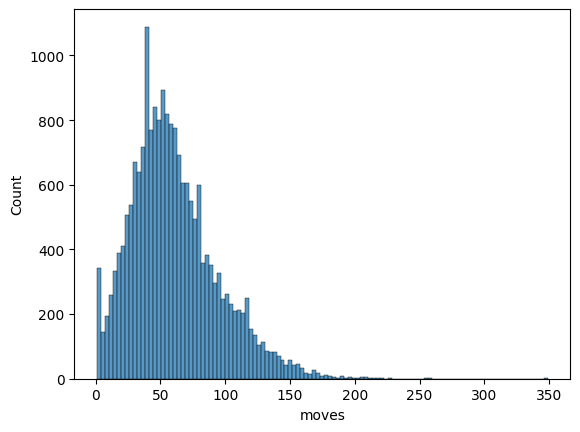

In [4]:
cts = df['moves'].apply(lambda x: len(x.split(' ')))
sns.histplot(data=cts)
plt.show()


In [225]:
def get_batch(data, batch_size, block_size): 
    idx = np.random.randint(0, len(data), size=batch_size, dtype=int)

    x = np.zeros((batch_size, block_size))
    y = np.zeros((batch_size, block_size))

    arr = data[idx].to_numpy()

    for i in range(batch_size): 
        arr_concate  = np.array(arr[i])[0:block_size]
        # [0 , 1, 2] - > [1,2,3]
        x[i, 0: (len(arr_concate)-1)] = arr_concate[0:(len(arr_concate)-1)]
        y[i, 0: (len(arr_concate)-1)] = arr_concate[1::]

    return torch.from_numpy(x).long().to(device), torch.from_numpy(y).long().to(device)

In [85]:
from datasets import load_dataset
import json

dataset = load_dataset('angeluriot/chess_games', streaming=True)['train']
n_rows = 1000
block_size = 200
min_elo = 2000

In [86]:
x = np.zeros((n_rows, block_size))
y = np.zeros((n_rows, block_size))

In [87]:
stoi = {'<PAD>': 0}
current_idx_stoi = 1
current_idx  = 0 

for ex in dataset:
    if (not ex['white_elo']) or (ex['white_elo'] < min_elo):
        continue

    game = ex['moves_san'][0:block_size]
    game_row = np.zeros(block_size)
    for j, move in enumerate(game): 
        if move not in stoi: 
            stoi[move] = current_idx_stoi
            current_idx_stoi += 1 
        game_row[j]= stoi[move] 
    
    x[current_idx, 0:block_size] = game_row
    y[current_idx, 0:(block_size-1)] = game_row[1::]

    if current_idx % 1000 == 0:
        print(f"Processed {current_idx} games")

    if current_idx == (n_rows-1):
        break 
    
    current_idx += 1 


x = x[0:current_idx, :]
y = y[0:current_idx, :]

x_torch = torch.from_numpy(x).long()
y_torch = torch.from_numpy(y).long()

torch.save(x_torch, "../data/processed/x.pt")
torch.save(y_torch, "../data/processed/y.pt")

itos = {i: ch for i, ch in enumerate(stoi)}

with open("../data/processed/stoi.json", "w") as f:
    json.dump(stoi, f, indent=4)

with open("../data/processed/itos.json", "w") as f:
    json.dump(itos, f, indent=4)

Processed 0 games


## Opening and batching

In [106]:
device = 'cpu'
x = torch.load('../data/processed/x.pt').to(device)
y = torch.load('../data/processed/y.pt').to(device)

with open('../data/processed/itos.json', 'r') as file:
    itos = json.load(file)
itos = {int(i): ch for i, ch in itos.items()}

with open('../data/processed/stoi.json', 'r') as file:
    stoi = json.load(file)

vocab_size = len(itos)

encode = lambda x : [stoi[move] for move in x]
decode = lambda x : [itos[d] for d in x]

In [117]:
n_rows = x.shape[0]

n = int(0.9 * n_rows)
train_data_x = x[:n]
train_data_y = y[:n]
val_data_x = x[n:]
val_data_y = y[n:]

In [126]:
def get_batch(split): 
    if split == 'train': 
        split_data_x, split_data_y = train_data_x, train_data_y
    else:
        split_data_x, split_data_y = val_data_x, val_data_y
    idx = np.random.randint(0, n_rows, size=batch_size, dtype=int)

    x = split_data_x[idx, : ]
    y = split_data_y[idx, : ]

    return x.to(device), y.to(device)


In [129]:
batch_size = 5
x,y = get_batch(split = 'train')
x

tensor([[   1,   19,    3,   97,    5,   12,   14,   66,   13,  227,   36,  461,
          303,  147,   34,   78,   70,   46,    7,   33,  399,  400,  240,  698,
           70,  131,   48,   33,  240,   77,  670,  277,  502,  287,  287,  176,
           17,  153,  699,  503,  294,   56,    5, 1006,  699,  228,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
        [   7,   12,   13,    6,   15,   10,   34,   16,  587,   14,  420,   82,
          130,    2,   19,  696,   81,   84,  587,   35,  146,   50,  491,  100,
          748,  294,   77, 

In [130]:
y

tensor([[  19,    3,   97,    5,   12,   14,   66,   13,  227,   36,  461,  303,
          147,   34,   78,   70,   46,    7,   33,  399,  400,  240,  698,   70,
          131,   48,   33,  240,   77,  670,  277,  502,  287,  287,  176,   17,
          153,  699,  503,  294,   56,    5, 1006,  699,  228,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
        [  12,   13,    6,   15,   10,   34,   16,  587,   14,  420,   82,  130,
            2,   19,  696,   81,   84,  587,   35,  146,   50,  491,  100,  748,
          294,   77,  292, 

In [102]:
vocab_size = list(itos.keys())[-1]

6379

## Chess game stuff

In [ ]:
import sys 
import os
import json 
from pathlib import Path
import time 
import chess 
from IPython.display import display, clear_output
import chess.svg

sys.path.append(str(Path(os.getcwd()).resolve().parent))

from config import config

import torch 
from stockfish import Stockfish
from src.models.model_base import GPT
stockfish = Stockfish(path="../misc/stockfish/stockfish-windows-armv8")

DATA_DIR = config.DATA_DIR
with open(DATA_DIR / 'processed' / 'itos.json', 'r') as file:
    itos = json.load(file)
itos = {int(i) : ch for i,ch in itos.items()} 
with open(DATA_DIR / 'processed' / 'stoi.json', 'r') as file:
    stoi = json.load(file)
vocab_size = len(itos)
device= config.device

In [149]:
decode = lambda x : [itos[val] for val in x]
encode = lambda x : [stoi[val] for val in x]

In [150]:
target_dir = Path(config.ROOT) / 'models' / config.save_name
target_dir = target_dir if target_dir.exists() else Path(config.ROOT)

files = list(target_dir.iterdir())
pt_files = [p for p in files if p.suffix == ".pt"]

pt_path = pt_files[0] if pt_files else None

In [151]:
model = GPT(
    vocab_size=vocab_size,
    n_embd=config.n_embd,
    n_head=config.n_head,
    n_layer=config.n_layer,
    block_size=config.block_size,
    dropout=config.dropout,
    device=config.device,
).to(device)

model.load_state_dict(torch.load(pt_path, map_location=device))
model.eval()

GPT(
  (token_embedding_table): Embedding(29275, 120)
  (position_embedding_table): Embedding(120, 120)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-2): 3 x Head(
            (key): Linear(in_features=120, out_features=40, bias=False)
            (query): Linear(in_features=120, out_features=40, bias=False)
            (value): Linear(in_features=120, out_features=40, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=120, out_features=120, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=120, out_features=480, bias=True)
          (1): ReLU()
          (2): Linear(in_features=480, out_features=120, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
     

In [ ]:
def play_game(model, stock_lvl = 1, display_game = False, delay = .5):
    
    def make_GPT_move(board):
        nonlocal illegal_move_count
        
        san_moves = []
        temp_board = chess.Board()
        for move in board.move_stack:
            san_moves.append(temp_board.san(move))
            temp_board.push(move)
        
        enc_game = encode(san_moves)
        idx = torch.tensor([enc_game]).to(device)
        
        # try the top move first
        move_idx = model.generate(idx, max_new_tokens=1)[0][-1].item()
        san_move = itos[move_idx]
        
        legal_san = [board.san(m) for m in board.legal_moves]
        
        if san_move in legal_san:
            board.push_san(san_move)
            return san_move
        
        # illegal move -- mask and resample
        illegal_move_count += 1
        probs = model.generate_probs(idx)[0]
        
        # build mask: set all illegal moves to 0
        legal_indices = [stoi[m] for m in legal_san if m in stoi]
        mask = torch.zeros_like(probs)
        mask[legal_indices] = 1
        probs = probs * mask
        probs = probs / probs.sum()
        
        move_idx = torch.multinomial(probs, num_samples=1).item()
        san_move = itos[move_idx]
        board.push_san(san_move)

    def make_stock_move(board):
        uci_moves = [move.uci() for move in board.move_stack]
        stockfish.make_moves_from_start(uci_moves)
        uci_move = stockfish.get_best_move()
        board.push_uci(uci_move)
    
    board = chess.Board()

    illegal_move_count = 0
    total_moves = 0
    size=250
    stockfish.set_skill_level(stock_lvl)

    while True:
        make_stock_move(board)
        total_moves += 1 
        if display_game: 
            clear_output(wait=True)
            display(chess.svg.board(board, size = size))

        if board.is_game_over():
            break

        make_GPT_move(board)
        total_moves += 1 
        if display_game: 
            time.sleep(delay)
            clear_output(wait=True)
            display(chess.svg.board(board,  size = size))

        if board.is_game_over():
            break

    outcome = board.outcome()
    if display_game: 
        print(outcome)
        print(f"Illegal moves: {illegal_move_count}, illegal rate {illegal_move_count/total_moves}")
    
    if outcome.winner is None: 
        winner = "draw"
    elif outcome.winner: 
        winner = 'stock'
    else:
        winner = 'model'

    output = {
        'illegal_moves' : illegal_move_count,
        'illegal_rate' : illegal_move_count/total_moves, 
        'stock_lvl' : stock_lvl,
        'winner' : winner,
        'game_length' : total_moves
    }
    return output 


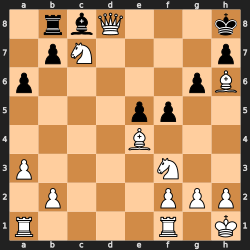

Outcome(termination=<Termination.CHECKMATE: 1>, winner=True)
Illegal moves: 16, illegal rate 0.3404255319148936


{'illegal_moves': 16,
 'illegal_rate': 0.3404255319148936,
 'stock_lvl': 1,
 'winner': 'stock',
 'game_length': 47}

In [192]:
play_game(model=model, stock_lvl=1, display_game=True, delay = .2)

In [201]:
for lvl in range(5,25,5):
    print(lvl)

5
10
15
20
